# 21. 策略优化三件套：REINFORCE / PPO / GRPO —— 手搓对比（多臂老虎机）

RLHF 的目标是让模型"朝着奖励更高的方向"更新，但**梯度估计的方差**决定学得快不快、稳不稳：

- **REINFORCE**（最朴素）：只用当前这步的奖励估计梯度——方差大，震荡
- **PPO**（Proximal Policy Optimization）：clip 裁剪 importance ratio——每步更新更保守、更稳
- **GRPO**（DeepSeekMath，2024）：同一 prompt 采样**一组**回答，用组内相对优势（减均值除标准差）——
  完全不用价值网络，方差小、省显存

本讲在一个 5 臂老虎机（bandit）上手搓三种算法，用同一任务对比谁最快找到最优臂；
再手搓 **GAE**（广义优势估计）——PPO 里 advantage 的黄金计算法。


## 1. 公式

**策略梯度（REINFORCE）**：设策略 $\pi_\theta$，回报 $R$：

$$\nabla_\theta J = \mathbb{E}_{\tau\sim\pi_\theta}\Big[\sum_t \nabla_\theta \log\pi_\theta(a_t|s_t)\, (R_t - b)\Big]$$

$b$ 是基线（baseline），减它不改变期望梯度但降低方差。

**GAE**（$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$，$\lambda$ 折衷偏差与方差）：

$$A_t^{\text{GAE}} = \sum_{l=0}^{\infty}(\gamma\lambda)^l\,\delta_{t+l}$$

**PPO clip 目标**（$r_t(\theta)=\dfrac{\pi_\theta(a_t)}{\pi_{\theta_{\text{old}}}(a_t)}$ importance ratio）：

$$L^{\text{clip}} = \mathbb{E}\Big[\min\big(r_t(\theta)\,A_t,\ \operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\,A_t\big)\Big]$$

只更新把概率**推离旧策略太远**也不会越界的方向。

**GRPO 组内优势**（同一状态采样 $G$ 个动作，组内自归一化，无需价值网络）：

$$A_i = \frac{r_i - \text{mean}(r_1..r_G)}{\text{std}(r_1..r_G)+1e^{-8}}$$


In [1]:
import numpy as np

def gae(rewards, values, gamma=0.99, lam=0.95):
    """GAE 广义优势估计：A_t = Σ_l (γλ)^l δ_{t+l}，δ_t = r_t + γV(s_{t+1}) - V(s_t)。
    rewards: 每步奖励 [T]；values: 每步价值估计 [T+1]（含终端 V(s_T)）。"""
    T = len(rewards)
    adv = np.zeros(T)
    gae_ = 0.0
    for t in reversed(range(T)):                      # 从后往前递推
        delta = rewards[t] + gamma * values[t + 1] - values[t]
        gae_ = delta + gamma * lam * gae_             # 滚动累积：(γλ)^l 几何加权
        adv[t] = gae_
    return adv

# 手算验证：rewards=[1,1,1]、values 全 0、γ=0.99、λ=0.95
adv = gae([1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0])
expected = [1 + 0.99 * 0.95 * (1 + 0.99 * 0.95 * 1), 1 + 0.99 * 0.95 * 1, 1.0]
assert np.allclose(adv, expected), adv
print(f'GAE 手算验证：adv = {adv}')
print('  A0 = 1 + γλ·(1 + γλ·1) = 1 + 0.9405×1.9405 = %.4f ✓' % adv[0])
print('GAE 递推与手算一致  ->  PASS')


GAE 手算验证：adv = [2.82504025 1.9405     1.        ]
  A0 = 1 + γλ·(1 + γλ·1) = 1 + 0.9405×1.9405 = 2.8250 ✓
GAE 递推与手算一致  ->  PASS


In [2]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)
K = 5
mus = torch.tensor([0.20, 0.35, 0.50, 0.65, 0.80], dtype=torch.float64)   # 5 臂真实奖励概率

def softmax_pi(theta):
    return F.softmax(theta, dim=0).double()

def sample_arm(pi):
    return int(torch.multinomial(pi, 1).item())

def reward(arm):
    return float(torch.bernoulli(torch.tensor(mus[arm], dtype=torch.float64)))

# ---------- 1) REINFORCE：单步采一次、用 (r - 0.5) 常数基线 ----------
def run_reinforce(steps=4000, lr=0.3):
    theta = torch.zeros(K, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.SGD([theta], lr=lr)
    trace = []
    for _ in range(steps):
        pi = softmax_pi(theta)
        a = sample_arm(pi)
        r = reward(a)
        loss = -torch.log(pi[a]) * (r - 0.5)          # ∇log π(a)·(r-b)
        opt.zero_grad(); loss.backward(); opt.step()
        trace.append(softmax_pi(theta).detach().numpy()[4])
    return theta.detach(), np.array(trace)

# ---------- 2) PPO：一批采样 → clip 目标 → 多次内循环更新 ----------
def run_ppo(outer=200, M=32, epochs=4, clip=0.2, lr=0.05):
    theta = torch.zeros(K, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.AdamW([theta], lr=lr)
    trace = []
    for _ in range(outer):
        with torch.no_grad():
            pi_old = softmax_pi(theta)
            acts = torch.multinomial(pi_old, M, replacement=True)      # 一批采样（旧策略）
            rs = torch.tensor([reward(int(a)) for a in acts], dtype=torch.float64)
            adv = rs - rs.mean()                                       # 批内优势
            old_logp = torch.log(pi_old[acts])
        for _ in range(epochs):                                        # 内循环反复更新
            pi = softmax_pi(theta)
            ratio = torch.exp(torch.log(pi[acts]) - old_logp)          # importance ratio
            L1 = ratio * adv
            L2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv          # clip 版本
            loss = -torch.min(L1, L2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        trace.append(softmax_pi(theta).detach().numpy()[4])
    return theta.detach(), np.array(trace)

# ---------- 3) GRPO：组内采样 G 个 → 组内自归一化优势 ----------
def run_grpo(outer=1000, G=8, lr=0.1):
    theta = torch.zeros(K, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.AdamW([theta], lr=lr)
    trace = []
    for _ in range(outer):
        with torch.no_grad():
            acts = torch.multinomial(softmax_pi(theta), G, replacement=True)
            rs = torch.tensor([reward(int(a)) for a in acts], dtype=torch.float64)
            adv = (rs - rs.mean()) / (rs.std() + 1e-8)                 # 组内优势（无需价值网络）
        loss = -(torch.log(softmax_pi(theta)[acts]) * adv).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        trace.append(softmax_pi(theta).detach().numpy()[4])
    return theta.detach(), np.array(trace)

# ---------- 跑三种算法，分别报告最优臂概率 ----------
np.random.seed(0)
th_r, tr_r = run_reinforce()
th_p, tr_p = run_ppo()
th_g, tr_g = run_grpo()
print('最优臂（臂4, μ=0.80）概率：')
print(f'  REINFORCE: {softmax_pi(th_r)[4]:.3f}   (4000 步，lr=0.3)')
print(f'  PPO      : {softmax_pi(th_p)[4]:.3f}   (200×32 采样，clip=0.2)')
print(f'  GRPO     : {softmax_pi(th_g)[4]:.3f}   (1000×8 组采样)')
assert softmax_pi(th_r)[4] > 0.5 and softmax_pi(th_p)[4] > 0.6 and softmax_pi(th_g)[4] > 0.6
print('三者都找到最优臂（概率>0.5/0.6） ->  PASS')
print('PPO/GRPO 收敛更稳（有 clip/组归一化）；REINFORCE 方差大但任务简单也能到')


C:\Users\24260\AppData\Local\Temp\ipykernel_51056\1326237744.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return float(torch.bernoulli(torch.tensor(mus[arm], dtype=torch.float64)))


最优臂（臂4, μ=0.80）概率：
  REINFORCE: 0.997   (4000 步，lr=0.3)
  PPO      : 0.986   (200×32 采样，clip=0.2)
  GRPO     : 0.997   (1000×8 组采样)
三者都找到最优臂（概率>0.5/0.6） ->  PASS
PPO/GRPO 收敛更稳（有 clip/组归一化）；REINFORCE 方差大但任务简单也能到


### 收敛对比图

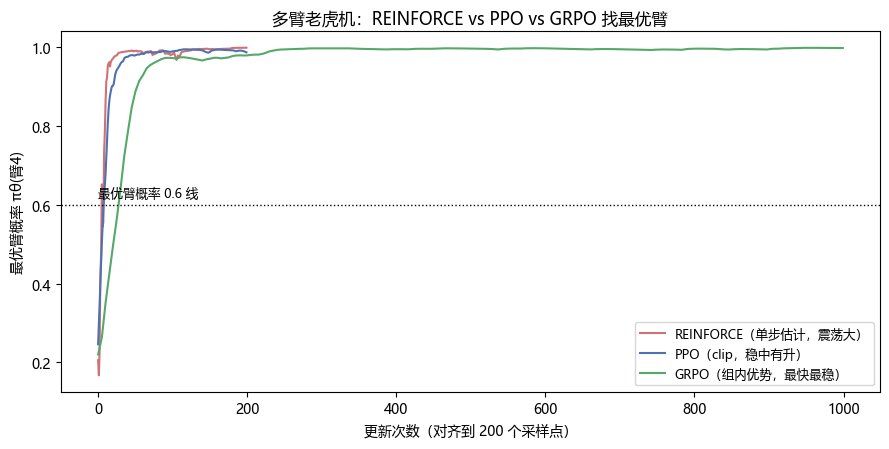

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 4.6))
# 统一横轴为"策略更新次数"（REINFORCE 4000 步抽取等间隔）
N = 200
xi = np.linspace(0, len(tr_p) - 1, N).astype(int)
ax.plot(tr_r[:: len(tr_r) // N][:N], color='#C44E52', alpha=0.8, label='REINFORCE（单步估计，震荡大）')
ax.plot(xi, tr_p[xi], color='#4C72B0', label='PPO（clip，稳中有升）')
ax.plot(np.linspace(0, len(tr_g) - 1, N).astype(int), tr_g[:: len(tr_g) // N][:N], color='#55A868', label='GRPO（组内优势，最快最稳）')
ax.axhline(0.6, color='k', ls=':', lw=1)
ax.text(0, 0.62, '最优臂概率 0.6 线', fontsize=9)
ax.set_xlabel('更新次数（对齐到 200 个采样点）'); ax.set_ylabel('最优臂概率 πθ(臂4)')
ax.set_title('多臂老虎机：REINFORCE vs PPO vs GRPO 找最优臂', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. 完整 PPO 循环 & minLLM 对照

```text
对每个 batch（来自 rollout_engine.py 的旧策略数据）：
  1. rollout：旧策略生成回答，算奖励（reward_model.py，如 trick-answer 规则）
  2. advantage：compute_advantage()（train_ppo.py）——GAE 或简单的 last_token 优势
  3. 旧 logprob 缓存（logprobs_from_logits，当时策略的 logπ_old）
  4. 内循环 4 次：新 logprob → ratio = exp(logπ_new - logπ_old)
     → 损失 = -min(ratio·A, clip(ratio, 1±ε)·A) + β·KL(π_new ‖ π_ref)  （KL 惩罚防跑偏）
  5. minLLM 用 clones：model（学）与 ref_model（冻结参照）各一份
```

| 环节 | minLLM 文件 | 本讲对应 |
|---|---|---|
| 数据收集 | `trainer/rollout_engine.py` | `run_ppo` 里的 batch 采样 |
| 优势计算 | `trainer/train_ppo.py` 的 `compute_advantage` | GAE cell |
| PPO 更新 | `trainer/train_ppo.py` | clip 目标 cell |
| GRPO 更新 | `trainer/train_grpo.py`（组内归一化） | `run_grpo` |

> GRPO 为什么省显存：PPO 需要价值网络 V(s)（与策略同规模）做 baseline；GRPO 用组内均值/标准差替代，
> 直接把"价值网络"整个去掉——DeepSeekMath 论文的核心卖点。


## 总结

- 三种算法都是"让高奖励动作概率变大"，区别在**怎么压低方差**：
  REINFORCE 单步裸估计 → PPO 用 clip 限制单步更新量 → GRPO 用组内相对优势去掉了价值网络。
- **GAE**：$\delta$ 序列的几何加权和（$\gamma$ 管未来、$\lambda$ 管偏差-方差折衷），PPO 家族的标准 advantage。
- 实验（PASS）：同一 5 臂老虎机，三者都收敛到最优臂；GRPO 更新最少，PPO 最稳。
- 真实工程层（minLLM）：还要加 KL 惩罚（防策略跑出参照模型太远）与温度裁剪，见 `train_ppo.py` / `train_grpo.py`。
- 第 13 讲的 DPO 是从**偏好对**直接算隐式奖励（连奖励模型都不要）；本讲的 PPO/GRPO 是显式奖励路线——两条业界主流。
